In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

In [18]:
filenames = [4]

labels_str = ['DDoS', 'Benign', 'DoS', 'Bot', 'FTP-BruteForce', 'SSH-BruteForce', 'Web']

filenames

[4]

In [19]:
for z in range(len(filenames)):
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    

    pca = PCA(n_components=2)

    val_encoded_pca = pca.fit_transform(val_encoded_df.drop(columns=['Label']).to_numpy())

    val_view_df = pd.DataFrame({0:val_encoded_pca[:,0], 1:val_encoded_pca[:,1]})

    val_view_df['Label'] = val_encoded_df['Label']

    custom_colors = [
        "#FF5733",  # Laranja avermelhado
        "#33FF57",  # Verde claro vibrante
        "#3357FF",  # Azul vivo
        "#FFFF33",  # Amarelo forte
        "#FF33FF",  # Magenta (rosa choque)
        "#33FFFF",  # Ciano claro
        "#990000",  # Vermelho escuro
        "#009900",  # Verde escuro
        "#000099",  # Azul marinho
        "#999900",  # Amarelo amarronzado/mostarda
        "#990099",  # Roxo intenso
        "#009999",  # Verde-água escuro
        "#CCCCCC",  # Cinza claro
        "#FF6600",  # Laranja forte (tipo tangerina)
        "#6600FF",  # Roxo azulado (índigo intenso)
    ]
    colors = {0: custom_colors[0],
            1: custom_colors[1],
            2: custom_colors[2],
            3: custom_colors[3],
            4: custom_colors[4],
            5: custom_colors[5],
            6: custom_colors[6],
            # 7: custom_colors[7],
            # 8: custom_colors[8],
            # 9: custom_colors[9],
            # 10: custom_colors[10],
            # 11: custom_colors[11],
            # 12: custom_colors[12],
            # 13: custom_colors[13],
            # 14: custom_colors[14],
            }
    val_view_df['Cor'] = val_view_df['Label'].map(colors)

    map_tipo = {0: labels_str[0], 
                1: labels_str[1], 
                2: labels_str[2], 
                3: labels_str[3], 
                4: labels_str[4], 
                5: labels_str[5], 
                6: labels_str[6], 
                # 7: labels_str[7], 
                # 8: labels_str[8], 
                # 9: labels_str[9], 
                # 10: labels_str[10], 
                # 11: labels_str[11], 
                # 12: labels_str[12], 
                # 13: labels_str[13], 
                # 14: labels_str[14], 
                }

In [28]:
val_sample_df = val_view_df[val_view_df['Label'] == 1].sample(n=100,random_state=123)
for i in range(3,len(labels_str)-1):
    val_sample_df = pd.concat([val_sample_df, val_view_df[val_view_df['Label'] == i].sample(n=100,random_state=123)], ignore_index=True)
val_sample_df

,0,1,Label,Cor
0,-0.011281,0.015967,1,#33FF57
1,-0.010740,0.016436,1,#33FF57
2,0.001850,0.023177,1,#33FF57
3,-0.011627,0.013682,1,#33FF57
4,-0.010687,0.016389,1,#33FF57
...,...,...,...,...
395,-0.006935,-0.039462,5,#33FFFF
396,-0.005662,-0.037665,5,#33FFFF
397,-0.006705,-0.039838,5,#33FFFF
398,-0.005662,-0.037665,5,#33FFFF


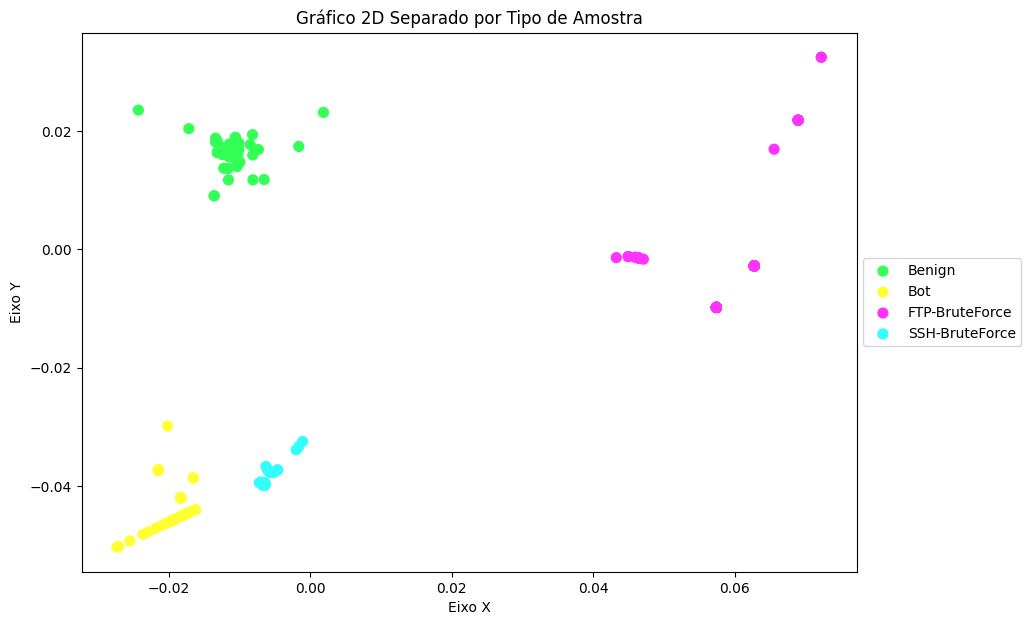

In [29]:
plt.figure(figsize=(10, 7))

for tipo in val_sample_df['Label'].unique():
    subset = val_sample_df[val_sample_df['Label'] == tipo]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50)

    
plt.title('Gráfico 2D Separado por Tipo de Amostra')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.show()